In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.shape

(9994, 21)

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [22]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.columns.tolist()

['Row_ID',
 'Order_ID',
 'Order_Date',
 'Ship_Date',
 'Ship_Mode',
 'Customer_ID',
 'Customer_Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal_Code',
 'Region',
 'Product_ID',
 'Category',
 'Sub-Category',
 'Product_Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [23]:
category_profit = df.groupby('Category')[['Sales', 'Profit']].sum()
category_profit['Margin'] = (category_profit['Profit'] / category_profit['Sales'] * 100).round(2)
category_profit

,Sales,Profit,Margin
Category,,,
Furniture,741999.7953,18451.2728,2.49
Office Supplies,719047.0320,122490.8008,17.04
Technology,836154.0330,145454.9481,17.40


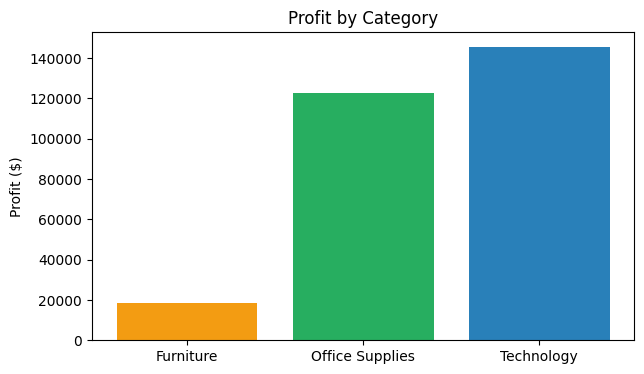

In [24]:
plt.figure(figsize=(7,4))
plt.bar(category_profit.index, category_profit['Profit'], color=['#f39c12', '#27ae60', '#2980b9'])
plt.title('Profit by Category')
plt.ylabel('Profit ($)')
plt.savefig('profit_by_category.png')
plt.show()

In [26]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
sub_profit

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


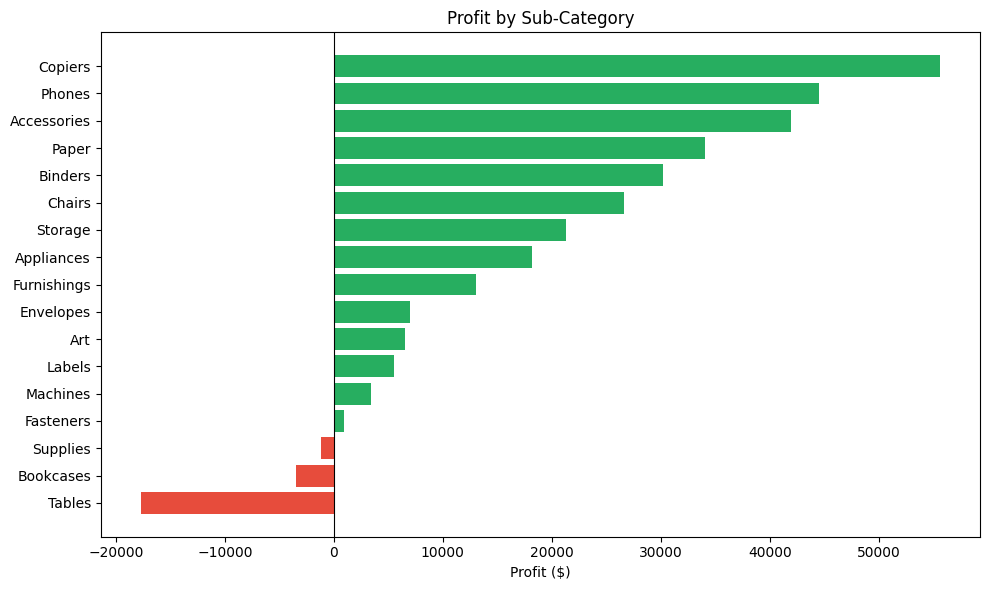

In [27]:
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in sub_profit]

plt.figure(figsize=(10,6))
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.savefig('subcategory_profit.png')
plt.show()

In [28]:
sub_profit[sub_profit < 0]

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995


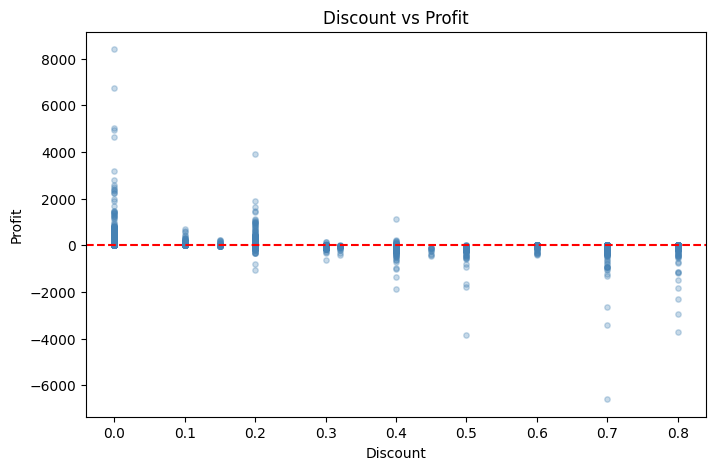

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.savefig('discount_vs_profit.png')
plt.show()

In [30]:
df['Discount'].corr(df['Profit'])

np.float64(-0.21948745637176803)

In [31]:
region_profit = df.groupby('Region')[['Sales', 'Profit']].sum()
region_profit['Margin'] = (region_profit['Profit'] / region_profit['Sales'] * 100).round(2)
region_profit.sort_values('Profit', ascending=False)

,Sales,Profit,Margin
Region,,,
West,725457.8245,108418.4489,14.94
East,678781.2400,91522.7800,13.48
South,391721.9050,46749.4303,11.93
Central,501239.8908,39706.3625,7.92


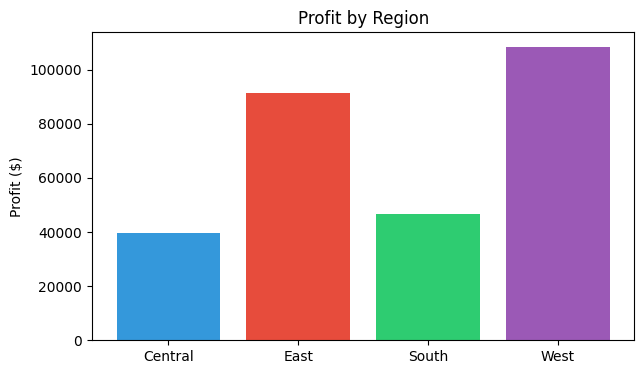

In [32]:
plt.figure(figsize=(7,4))
plt.bar(region_profit.index, region_profit['Profit'], color=['#3498db','#e74c3c','#2ecc71','#9b59b6'])
plt.title('Profit by Region')
plt.ylabel('Profit ($)')
plt.savefig('profit_by_region.png')
plt.show()

In [33]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()
monthly

,Sales
Month,
2014-01,14236.8950
2014-02,4519.8920
2014-03,55691.0090
2014-04,28295.3450
2014-05,23648.2870
2014-06,34595.1276
2014-07,33946.3930
2014-08,27909.4685
2014-09,81777.3508


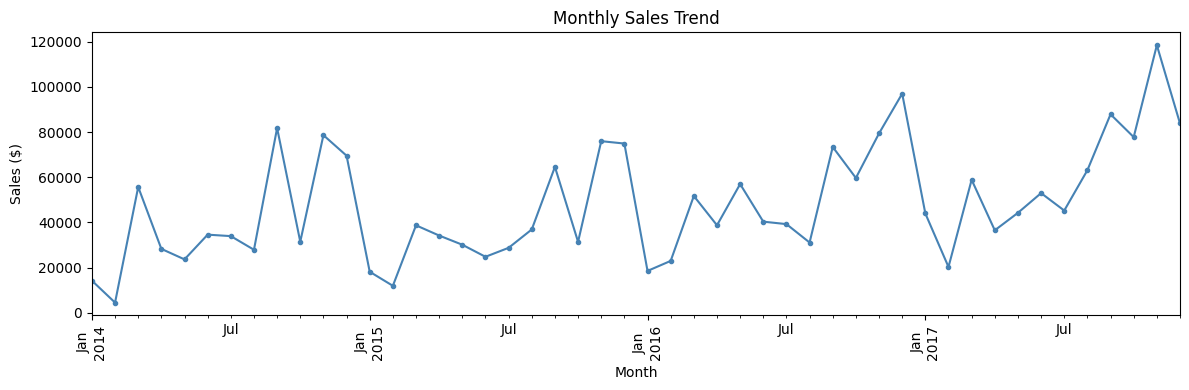

In [34]:
plt.figure(figsize=(12,4))
monthly.plot(color='steelblue', marker='o', markersize=3)
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

In [35]:
df['Discount_Band'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=['No Discount', 'Low', 'Medium', 'High'])

df.groupby('Discount_Band', observed=True)['Profit'].mean().round(2)

,Profit
Discount_Band,
No Discount,66.90
Low,26.50
Medium,-77.86
High,-106.71


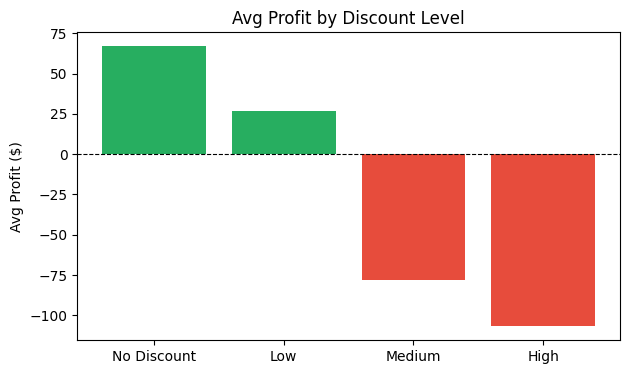

In [36]:
discount_avg = df.groupby('Discount_Band', observed=True)['Profit'].mean()

plt.figure(figsize=(7,4))
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in discount_avg]
plt.bar(discount_avg.index, discount_avg.values, color=colors)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Avg Profit by Discount Level')
plt.ylabel('Avg Profit ($)')
plt.savefig('discount_bands.png')
plt.show()

In [37]:
df.to_csv('superstore_clean.csv', index=False)
files.download('superstore_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>